In [2]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
from torch.nn.functional import interpolate

from datasets import load_dataset
from inpaintingStart import *
import argparse

from PIL import Image
import gradio as gr
from imagenet_en_cn import IMAGENET_1K_CLASSES
from omegaconf import OmegaConf

import torch
from transformers import T5EncoderModel, AutoTokenizer

from pixelflow.scheduling_pixelflow import PixelFlowScheduler
from pixelflow.pipeline_pixelflow import PixelFlowPipeline
from pixelflow.utils import config as config_utils
from pixelflow.utils.misc import seed_everything

from sampler import PixelFlowPipeline2
from sampler2 import PixelFlowPipeline3

import matplotlib.pyplot as plt
import imageio
import math
import copy
from pathlib import Path
from einops import rearrange
# ds = load_dataset("ILSVRC/imagenet-1k")

/home/ruy45/anaconda3/envs/pixelflow/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
num_stages = 4 # config.scheduler.num_stages
inference_each_step = 10
class_label = 10
NUM_EXAMPLES = 4
resolution = 256
num_Langevin = 100
lr_base = 1e-4
lr_min_ratio = 1e-2
sigma_n =0.05
proj = True
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
output_dir = './pretrained_models/c2img'
A_opr = get_operator("inpainting", mask_type='box', mask_len_range=(80, 160), mask_prob_range=None, resolution=resolution, device=device, sigma=sigma_n)
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
config = OmegaConf.load(f"{output_dir}/config.yaml")
model = config_utils.instantiate_from_config(config.model).to(device)
print(f"Num of parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
ckpt = torch.load(f"{output_dir}/model.pt", map_location="cpu", weights_only=False)
model.load_state_dict(ckpt, strict=True)
model.eval()
text_encoder = None
tokenizer = None
scheduler = PixelFlowScheduler(config.scheduler.num_train_timesteps, num_stages=config.scheduler.num_stages, gamma=-1/3)
scheduler_copy = copy.deepcopy(scheduler)
sampler_pipeline = PixelFlowPipeline3(scheduler_copy,model,text_encoder=text_encoder,tokenizer=tokenizer, max_token_length=512,)

Starting Initialization...
Num of parameters: 676611120


In [ ]:
data_dir = '/home/../mnt/data3/ruy45/dataset/imageNet256/ILSVRC/Data/CLS-LOC/train/'

def center_crop_arr(pil_image, image_size):
    while min(*pil_image.size) >= 2 * image_size:
        pil_image = pil_image.resize(
            tuple(x // 2 for x in pil_image.size), resample=Image.BOX
        )

    scale = image_size / min(*pil_image.size)
    pil_image = pil_image.resize(
        tuple(round(x * scale) for x in pil_image.size), resample=Image.BICUBIC
    )

    arr = np.array(pil_image)
    crop_y = (arr.shape[0] - image_size) // 2
    crop_x = (arr.shape[1] - image_size) // 2
    return Image.fromarray(arr[crop_y: crop_y + image_size, crop_x: crop_x + image_size])

transform = transforms.Compose([
    transforms.Lambda(lambda pil_image: center_crop_arr(pil_image, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=True)])

dataset = ImageFolder(data_dir, transform=transform)


if class_label:
    # target_class_name = 'n01440764'   # If class label available
    # class_label = dataset.class_to_idx[target_class_name]
    class_indices = [i for i, (_, y) in enumerate(dataset.samples) if y == class_label]
    perm = torch.randperm(len(class_indices))[:NUM_EXAMPLES]
    selected_indices = [class_indices[i] for i in perm]
    gt = torch.stack([dataset[i][0] for i in selected_indices], dim=0)
    labels = [dataset[i][1] for i in selected_indices]
else:
    idx = torch.randperm(len(dataset))[:NUM_EXAMPLES]
    gt = torch.stack([dataset[i][0] for i in idx], dim=0) 
    labels = [dataset[i][1] for i in idx]
# y = A_opr.measure(gt).to(device)

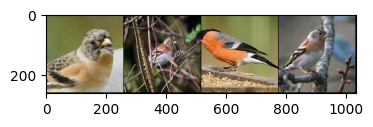

In [4]:
xt_vis = (gt.float() * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(xt_vis.cpu(), nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))

In [5]:
import random
batch_size = 16
stage_indices = list(range(config.scheduler.num_stages)) * (batch_size // config.scheduler.num_stages + 1)
stage_indices = stage_indices[:batch_size]

random.shuffle(stage_indices)
stage_indices = torch.tensor(stage_indices, dtype=torch.int32)
timesteps = torch.randint(0, config.scheduler.num_train_timesteps, (16,))
for stage_idx in range(config.scheduler.num_stages):
    corrected_stage_idx = config.scheduler.num_stages - stage_idx - 1
    print(stage_idx, corrected_stage_idx)
    stage_select_indices = timesteps[stage_indices == corrected_stage_idx]
    Timesteps = scheduler_copy.Timesteps_per_stage[corrected_stage_idx][stage_select_indices].float()
    batch_size_select = Timesteps.shape[0]
    start_t, end_t = scheduler_copy.start_t[corrected_stage_idx], scheduler_copy.end_t[corrected_stage_idx]
    t_select = scheduler_copy.t_window_per_stage[corrected_stage_idx][stage_select_indices].flatten()
    print(stage_select_indices, Timesteps, start_t, end_t, t_select)


0 3
tensor([932, 568, 934, 393]) tensor([980.2212, 878.1992, 980.7818, 829.1501]) 0.6000000000000001 1.0 tensor([0.9320, 0.5680, 0.9340, 0.3930], dtype=torch.float64)
1 2
tensor([974,  40, 115, 873]) tensor([711.3820, 437.7200, 459.6950, 681.7890]) 0.3333333333333333 0.75 tensor([0.9740, 0.0400, 0.1150, 0.8730], dtype=torch.float64)
2 1
tensor([594, 415, 622, 716]) tensor([324.0940, 279.1650, 331.1220, 354.7160]) 0.14285714285714285 0.5 tensor([0.5940, 0.4150, 0.6220, 0.7160], dtype=torch.float64)
3 0
tensor([646, 790, 773, 910]) tensor([113.0500, 138.2500, 135.2750, 159.2500]) 0.0 0.25 tensor([0.6460, 0.7900, 0.7730, 0.9100], dtype=torch.float64)


In [5]:
for i in range(4):
    print(scheduler_copy.Timesteps_per_stage[i][0], scheduler_copy.Timesteps_per_stage[i][-1])
    print("start_t, end_t", scheduler_copy.start_t[i], scheduler_copy.end_t[i])

tensor(0., dtype=torch.float64) tensor(174.8250, dtype=torch.float64)
start_t, end_t 0.0 0.25
tensor(175., dtype=torch.float64) tensor(425.7490, dtype=torch.float64)
start_t, end_t 0.14285714285714285 0.5
tensor(426., dtype=torch.float64) tensor(718.7070, dtype=torch.float64)
start_t, end_t 0.3333333333333333 0.75
tensor(719., dtype=torch.float64) tensor(999., dtype=torch.float64)
start_t, end_t 0.6000000000000001 1.0


In [ ]:
def sample_block_noise(scheduler, bs, ch, height, width, eps=1e-6):
    gamma = scheduler.gamma
    dist = torch.distributions.multivariate_normal.MultivariateNormal(torch.zeros(4), torch.eye(4) * (1 - gamma) + torch.ones(4, 4) * gamma + eps * torch.eye(4))
    block_number = bs * ch * (height // 2) * (width // 2)
    noise = torch.stack([dist.sample() for _ in range(block_number)]) # [block number, 4]
    noise = rearrange(noise, '(b c h w) (p q) -> b c (h p) (w q)',b=bs,c=ch,h=height//2,w=width//2,p=2,q=2)
    return noise
def T_to_t_linear(Timesteps, t, T):
    T_end = Timesteps[-1]
    T_start = Timesteps[0]
    t_end = t[-2]
    t_start = t[0]
    k = (T_end - T_start) / (t_end - t_start)
    b = T_start - t_start * k
    return (T-b)/k
def get_xt_from_x0(scheduler, Timesteps, x0, stage_idx, T, stage_noise = None, last_stage_xt = None, renoise = False):
    # When you set last_stage_xt = None, you do interpolate. If it is the x_end_{k+1}, then you get x_start_{k} by renoising.
    if stage_idx >0 and T == scheduler.Timesteps_per_stage[stage_idx][0] and renoise:
        print(f"New stage renoising! T = {T}, stage = {stage_idx}.")
        assert last_stage_xt != None, f"You need to input x_e_{stage_idx} to get x_s_{stage_idx+1}"
        xt = last_stage_xt
        height, width = xt.shape[-2],xt.shape[-1]
        height, width = height * 2, width * 2
        xt = F.interpolate(xt, size=(height, width), mode='nearest')
        original_start_t = scheduler.original_start_t[stage_idx]
        gamma = scheduler.gamma
        alpha = 1 / (math.sqrt(1 - (1 / gamma)) * (1 - original_start_t) + original_start_t)
        beta = alpha * (1 - original_start_t) / math.sqrt(- gamma)

        noise = sample_block_noise(scheduler, *xt.shape)
        noise = noise.to(device=device, dtype=xt.dtype)
        xt = alpha * xt + beta * noise
        return xt
    else:
        start_t, end_t = scheduler.start_t[stage_idx], scheduler.end_t[stage_idx]
        print(f"Start T: {start_t}")
        resolution = x0.shape[-1]
        pixel_values_end = x0
        pixel_values_start = x0
        if stage_idx < num_stages - 1:
            # pixel_values_end
            for downsample_idx in range(1, num_stages - stage_idx):
                pixel_values_end = F.interpolate(pixel_values_end, (resolution // (2 ** downsample_idx), resolution // (2 ** downsample_idx)), mode="bilinear")

            # pixel_values_start
        
        for downsample_idx in range(1, num_stages - stage_idx + 1):
            pixel_values_start = F.interpolate(pixel_values_start, (resolution // (2 ** downsample_idx), resolution // (2 ** downsample_idx)), mode="bilinear")
        # upsample pixel_values_start
        end_height, end_width = pixel_values_end.shape[-1], pixel_values_end.shape[-2]
        pixel_values_start = F.interpolate(pixel_values_start, (end_height, end_width), mode="nearest")

        if stage_noise == None: 
            noise = torch.randn_like(pixel_values_end)
        else:
            noise = stage_noise
        pixel_values_end = end_t * pixel_values_end + (1.0 - end_t) * noise
        # print(pixel_values_end.shape, pixel_values_start.shape, noise.shape)
        pixel_values_start = start_t * pixel_values_start + (1.0 - start_t) * noise

        # Ts = scheduler.Timesteps_per_stage[stage_idx].to(torch.float64)
        # k = int(torch.argmin(torch.abs(Ts - T)).item())              # nearest index
        # t_select = torch.tensor(scheduler.t_window_per_stage[stage_idx][k].item(), dtype = torch.float32, device = device) 
        t_select = T_to_t_linear(Timesteps, scheduler.t, T).to(device)
        xt = t_select.float() * pixel_values_end.to(device) + (1.0 - t_select.float()) * pixel_values_start.to(device)
        # print(start_t, end_t, T, t_select)
        return xt
    

In [7]:
# scheduler.Timesteps_per_stage[2]
# scheduler.t_window_per_stage[0]
# scheduler.original_start_t

In [8]:
T = 171.6750
stage_idx = 0
Ts = scheduler.Timesteps_per_stage[stage_idx].to(torch.float64)
k = int(torch.argmin(torch.abs(Ts - T)).item()) 
Ts[k]

tensor(171.6750, dtype=torch.float64)

In [9]:
def get_stage_noise(coarse_noise):
    # coarse: nearest upsample then normalize the block-constant basis
    coarse = F.interpolate(coarse_noise, scale_factor=2, mode="nearest") / 2.0
    addition = torch.randn_like(coarse)

    # subtract 2x2 block mean -> enforce sum-zero per block (project to orthogonal complement)
    block_mean = F.avg_pool2d(addition, kernel_size=2, stride=2)                 # (B,C,32,32)
    block_mean_up = F.interpolate(block_mean, scale_factor=2, mode="nearest")  # (B,C,64,64)
    noise_orth = addition - block_mean_up

    stage_noise = coarse + noise_orth
    return stage_noise

In [14]:
import os
x0s = []
seed_everything(0)
Timesteps = torch.tensor([[  0.0000,  19.4250,  38.8500,  58.2750,  77.7000,  97.1250, 116.5500,
        135.9750, 155.4000, 174.8250], [175.0000, 202.8610, 230.7220, 258.5830, 286.4440, 314.3050, 342.1660,
        370.0270, 397.8880, 425.7490], [426.0000, 458.5230, 491.0460, 523.5690, 556.0920, 588.6150, 621.1380,
        653.6610, 686.1840, 718.7070], [719.0000, 750.1111, 781.2222, 812.3333, 843.4444, 874.5556, 905.6667,
        936.7778, 967.8889, 999.0000]], dtype = torch.float32, device = device)
stages = [0, 1, 2, 3]
for stage_idx in stages:
    if stage_idx == 0:
        stage_noise = torch.randn(NUM_EXAMPLES, 3, 32,32).float().to(device)
    else:
        stage_noise = get_stage_noise(stage_noise).float().to(device)
        # stage_noise = F.interpolate(stage_noise, (32*2**stage_idx, 32*2**stage_idx), mode="nearest") 
        # freedom_added = torch.randn(NUM_EXAMPLES, 3, 32*2**stage_idx, 32*2**stage_idx).float().to(device)
        # stage_noise =  1/2*stage_noise + math.sqrt(3/4)*freedom_added
    for T in Timesteps[stage_idx]:
        print(f"Stage:{stage_idx}, Timesteps: {T}")
        xt = get_xt_from_x0(scheduler, Timesteps[stage_idx], gt.to(device), stage_idx, T, stage_noise = None, last_stage_xt = None, renoise = False) #Get x_t with interpolation only!
        # if stage_idx >0 and T == scheduler.Timesteps_per_stage[stage_idx][0]:
        #       xt = get_xt_from_x0(scheduler, Timesteps[stage_idx], gt, stage_idx, T, last_stage_xt = xt)
        # else:
        #     #     try:
        #     #           xt, stage_noise = get_xt_from_x0(scheduler, Timesteps[stage_idx], gt, stage_idx, T, stage_noise = stage_noise, last_stage_xt = None)
        #     #           print(f"Fix noise at {T}")
        #     #     except:
        #     #           print(f"Initialize noise at {T}")
        #     #           xt, stage_noise = get_xt_from_x0(scheduler, Timesteps[stage_idx], gt, stage_idx, T, stage_noise = None, last_stage_xt = None)
        #     xt = get_xt_from_x0(scheduler, Timesteps[stage_idx], gt.to(device), stage_idx, T, stage_noise = stage_noise, last_stage_xt = None)
        with torch.autocast("cuda", dtype=torch.bfloat16), torch.no_grad():
            samples = sampler_pipeline(prompt=[class_label] * NUM_EXAMPLES,
                                            height=resolution,
                                            width=resolution,
                                            num_inference_steps=2,
                                            guidance_scale=0.0,
                                            num_images_per_prompt=1,
                                            device=device,
                                            shift=1.0,
                                            use_ode_dopri5=False,
                                            xt = xt,          
                                            start_stage = stage_idx,             
                                            start_T = T,
                                            noises = None,          
                                            normalized_x0_hat = False,
                                            verbose = False)
            x0s.append(samples.cpu().float().numpy())



Stage:0, Timesteps: 0.0
Start T: 0.0
Stage:0, Timesteps: 19.424999237060547
Start T: 0.0
Stage:0, Timesteps: 38.849998474121094
Start T: 0.0
Stage:0, Timesteps: 58.275001525878906
Start T: 0.0
Stage:0, Timesteps: 77.69999694824219
Start T: 0.0
Stage:0, Timesteps: 97.125
Start T: 0.0
Stage:0, Timesteps: 116.55000305175781
Start T: 0.0
Stage:0, Timesteps: 135.97500610351562
Start T: 0.0
Stage:0, Timesteps: 155.39999389648438
Start T: 0.0
Stage:0, Timesteps: 174.8249969482422
Start T: 0.0
Stage:1, Timesteps: 175.0
Start T: 0.14285714285714285
Stage:1, Timesteps: 202.86099243164062
Start T: 0.14285714285714285
Stage:1, Timesteps: 230.7220001220703
Start T: 0.14285714285714285
Stage:1, Timesteps: 258.5830078125
Start T: 0.14285714285714285
Stage:1, Timesteps: 286.4440002441406
Start T: 0.14285714285714285
Stage:1, Timesteps: 314.30499267578125
Start T: 0.14285714285714285
Stage:1, Timesteps: 342.1659851074219
Start T: 0.14285714285714285
Stage:1, Timesteps: 370.0270080566406
Start T: 0.1428

In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter

# =========================
# 0) 你已有的数据（生成代码不改）
# 需要已存在：x0s, gt, Timesteps, stages
# =========================

plot_idx = 0  # 可视化 batch 里的第几张

# =========================
# 1) 自动重建 T_list / stage_list（不改生成代码的关键）
# =========================
def build_T_and_stage_list(Timesteps, stages, expected_len=None):
    T_list, stage_list = [], []
    for s in stages:
        for T in Timesteps[s]:
            T_list.append(float(T.item() if isinstance(T, torch.Tensor) else T))
            stage_list.append(int(s))

    # 对齐长度（避免你某次生成没跑满40帧等情况）
    if expected_len is not None:
        L = min(expected_len, len(T_list))
        return T_list[:L], stage_list[:L]
    return T_list, stage_list

T_list, stage_list = build_T_and_stage_list(Timesteps, stages, expected_len=len(x0s))

# =========================
# 2) 你已有的工具函数（保留风格 + 做一点稳健化）
# =========================
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().float().cpu().numpy()
    return np.asarray(x)

def to_display_image(x, batch_idx=0):
    x = to_numpy(x)

    # 如果有 batch 维，取指定 batch
    if x.ndim == 4:
        if not (0 <= batch_idx < x.shape[0]):
            raise IndexError(f"batch_idx={batch_idx} out of range for batch size {x.shape[0]}")
        x = x[batch_idx]

    # CHW -> HWC
    if x.ndim == 3 and x.shape[0] in (1, 3):
        x = np.transpose(x, (1, 2, 0))

    # 如果是单通道 HWC，压成 HW
    if x.ndim == 3 and x.shape[-1] == 1:
        x = x[..., 0]

    return x

def make_error_map(x_img, target_img):
    x = x_img.astype(np.float32)
    y = target_img.astype(np.float32)

    if x.shape != y.shape:
        raise ValueError(f"Shape mismatch: x {x.shape}, target {y.shape}")

    diff = x - y

    if diff.ndim == 2:
        err = np.abs(diff)
    elif diff.ndim == 3:
        err = np.linalg.norm(diff, axis=-1)  # per-pixel L2 over channels
    else:
        raise ValueError(f"Unsupported ndim for visualization: {diff.ndim}")

    return err

def to_01(img):
    """
    更稳健：把 [-1,1] / [0,1] / [0,255] 都统一到 [0,1] 显示
    """
    img = img.astype(np.float32)
    mn, mx = float(img.min()), float(img.max())

    # 典型 [-1,1]
    if mn < -0.05 and mx <= 1.05:
        img = img * 0.5 + 0.5
        return np.clip(img, 0, 1)

    # 典型 [0,255]
    if mx > 1.5:
        return np.clip(img / 255.0, 0, 1)

    # 默认 [0,1]
    return np.clip(img, 0, 1)

def to_scalar(x):
    if isinstance(x, torch.Tensor):
        return float(x.detach().item())
    return float(x)

def format_T(x, int_digits=4, frac_digits=3):
    width = int_digits + 1 + frac_digits
    return f"{float(x):0{width}.{frac_digits}f}"

# =========================
# 3) 准备 x0s / target（显示域对齐）
# =========================
# x0s: list of np arrays [B,C,H,W]
x0s_img = [to_display_image(x, batch_idx=plot_idx) for x in x0s]

# target 用 gt（你上面生成代码里有 gt）
target_img = to_display_image(gt, batch_idx=plot_idx)

# 统一到 [0,1] 再算误差（最直观；如果你想在模型域算，把 to_01 去掉即可）
x0s_disp = [to_01(x) for x in x0s_img]
target_disp = to_01(target_img)

assert len(T_list) == len(x0s_disp), f"T_list({len(T_list)}) must match x0s({len(x0s_disp)})"
assert len(stage_list) == len(x0s_disp), f"stage_list({len(stage_list)}) must match x0s({len(x0s_disp)})"

error_maps = [make_error_map(x, target_disp) for x in x0s_disp]
global_err_max = max(float(e.max()) for e in error_maps)
global_err_max = max(global_err_max, 1e-8)

# MAE/MSE（按显示域计算）
mae = [float(np.mean(np.abs(x - target_disp))) for x in x0s_disp]
mse = [float(np.mean((x - target_disp) ** 2)) for x in x0s_disp]

# =========================
# 4) 画图 + 保存 MP4
# =========================
save_dir = "./vis/test_noise_addition"
os.makedirs(save_dir, exist_ok=True)
mp4_path = os.path.join(save_dir, f"interpolated_x_end_plot{plot_idx}_STEP2.mp4")

fps = 4

fig = plt.figure(figsize=(7, 14))
gs = fig.add_gridspec(
    nrows=3, ncols=2,
    width_ratios=[20, 1],
    height_ratios=[1, 1, 1],
    wspace=0.05,
    hspace=0.08
)

ax_err = fig.add_subplot(gs[0, 0])
cax    = fig.add_subplot(gs[0, 1])
ax_x0  = fig.add_subplot(gs[1, 0])
ax_tgt = fig.add_subplot(gs[2, 0])
fig.add_subplot(gs[1, 1]).axis("off")
fig.add_subplot(gs[2, 1]).axis("off")

writer = FFMpegWriter(fps=fps)

with writer.saving(fig, mp4_path, dpi=150):
    for i, (x_img, err_map) in enumerate(zip(x0s_disp, error_maps)):
        T_val = T_list[i]
        s_val = stage_list[i]
        mae_val = mae[i]
        mse_val = mse[i]

        ax_err.clear(); ax_x0.clear(); ax_tgt.clear(); cax.clear()

        fig.suptitle(
            f"Frame {i} | stage={s_val} | T={format_T(T_val)} | "
            f"MSE={mse_val:.6f} | MAE={mae_val:.6f}",
            fontsize=12, y=0.995
        )

        # error heatmap
        im0 = ax_err.imshow(
            err_map, cmap="hot",
            vmin=0.0, vmax=global_err_max,
            aspect="equal"
        )
        ax_err.set_title("Error Heatmap", fontsize=10)
        ax_err.axis("off")
        cbar = fig.colorbar(im0, cax=cax)
        cbar.set_label("Error", fontsize=9)
        cbar.ax.tick_params(labelsize=8)

        # x0
        if x_img.ndim == 2:
            ax_x0.imshow(x_img, cmap="gray", vmin=0, vmax=1, aspect="equal")
        else:
            ax_x0.imshow(x_img, aspect="equal")
        ax_x0.set_title("x0", fontsize=10)
        ax_x0.axis("off")

        # target
        if target_disp.ndim == 2:
            ax_tgt.imshow(target_disp, cmap="gray", vmin=0, vmax=1, aspect="equal")
        else:
            ax_tgt.imshow(target_disp, aspect="equal")
        ax_tgt.set_title("target (gt)", fontsize=10)
        ax_tgt.axis("off")

        writer.grab_frame()

plt.close(fig)
print(f"Saved MP4 to: {mp4_path}")

Saved MP4 to: ./vis/test_noise_addition/x_end_plot0.mp4


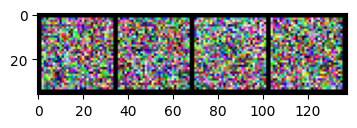

In [47]:
xt_vis = (xT.float() * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(xt_vis.cpu(), nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))

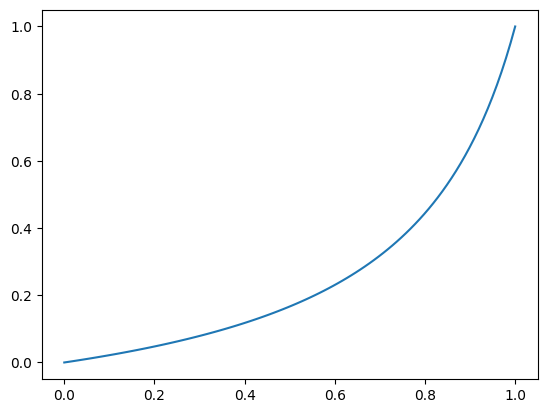

In [26]:
shift = 5
t = np.linspace(0, 1, 100)
t_ = t / (shift  + (1 - shift) * t)
plt.plot(t, t_)

In [54]:
@torch.no_grad()
def make_noise_yours(B=512, C=3, H=32, W=32, device="cuda"):
    n = torch.randn(B, C, H, W, device=device)
    u = F.interpolate(n, scale_factor=2, mode="nearest")  # 64x64
    g = torch.randn_like(u)
    y = 0.5 * u + math.sqrt(3/4) * g
    return y  # (B,C,64,64)

@torch.no_grad()
def make_noise_projected(B=512, C=3, H=32, W=32, device="cuda"):
    n = torch.randn(B, C, H, W, device=device)
    coarse = F.interpolate(n, scale_factor=2, mode="nearest") / 2.0
    g = torch.randn_like(coarse)
    # subtract per-2x2 block mean => sum-zero in each 2x2 block
    m = F.avg_pool2d(g, kernel_size=2, stride=2)
    m_up = F.interpolate(m, scale_factor=2, mode="nearest")
    g_orth = g - m_up
    y = coarse + g_orth
    return y  # (B,C,64,64)

@torch.no_grad()
def block_neighbor_corr(y):
    """
    Estimate Corr( pixel, its right neighbor ) within 2x2 blocks.
    We'll sample positions where (h,w) are the top-left of a 2x2 block.
    """
    B,C,H,W = y.shape
    # take top-left pixels of each 2x2 block
    a = y[:, :, 0::2, 0::2]                 # (B,C,H/2,W/2)
    b = y[:, :, 0::2, 1::2]                 # right neighbor in same block
    # flatten
    a = a.reshape(-1)
    b = b.reshape(-1)
    a = a - a.mean()
    b = b - b.mean()
    corr = (a*b).mean() / (a.std(unbiased=False) * b.std(unbiased=False) + 1e-12)
    return corr.item()

device = "cuda:1" if torch.cuda.is_available() else "cpu"

y1 = make_noise_yours(device=device)
y2 = make_noise_projected(device=device)

print("Your mix (expected ~0.25):", block_neighbor_corr(y1))
print("Projected  (expected ~0.00):", block_neighbor_corr(y2))
print("Var check:", y1.var().item(), y2.var().item())

Your mix (expected ~0.25): 0.25061941146850586
Projected  (expected ~0.00): -0.0006632640142925084
Var check: 0.9994291663169861 1.0000413656234741


In [51]:
@torch.no_grad()
def estimate_block_cov(y):
    # take one fixed 2x2 block position, e.g. top-left at (0,0)
    blk = y[:, :, 0:2, 0:2]        # (B,C,2,2)
    v = blk.reshape(blk.shape[0], blk.shape[1], 4)  # (B,C,4)
    v = v.reshape(-1, 4)           # combine B and C => (B*C,4)
    v = v - v.mean(dim=0, keepdim=True)
    cov = (v.T @ v) / v.shape[0]
    return cov.cpu()

cov1 = estimate_block_cov(y1)
cov2 = estimate_block_cov(y2)
print("Cov block (your mix):\n", cov1)
print("Cov block (projected):\n", cov2)

Cov block (your mix):
 tensor([[1.0055, 0.2074, 0.2639, 0.2403],
        [0.2074, 0.9776, 0.2692, 0.2308],
        [0.2639, 0.2692, 1.0316, 0.2509],
        [0.2403, 0.2308, 0.2509, 1.0096]])
Cov block (projected):
 tensor([[ 1.0543, -0.0166, -0.0356,  0.0063],
        [-0.0166,  0.9653, -0.0044,  0.0360],
        [-0.0356, -0.0044,  0.9827, -0.0389],
        [ 0.0063,  0.0360, -0.0389,  0.9929]])
